In [1]:
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

 cupy not imported 
2.2.1


In [3]:
N = 8000
mult = 2*2
span = 2
x = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
y = np.sin(1*1*np.pi*x[:,0])*np.sin(3*1*np.pi*x[:,1])
xt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
yt = np.sin(1*1*np.pi*xt[:,0])*np.sin(3*1*np.pi*xt[:,1])

In [4]:
print(x[:10,:])
print(y[:10])

[[-0.52941519  0.33575089]
 [ 0.34768782  0.18066326]
 [ 0.61816075  0.22029398]
 [-0.30249357  0.31087215]
 [-0.41744914  0.2856439 ]
 [ 0.8579078   0.63534587]
 [-0.45733133  0.63146674]
 [-0.32616477  0.0012935 ]
 [ 0.08304532 -0.6520367 ]
 [-0.51669783 -0.66779179]]
[ 0.02268571  0.87997296  0.81537271 -0.17094814 -0.41995187 -0.12559656
  0.32277771 -0.01041751  0.03545394  0.01058926]


In [5]:
xc = (x*128).astype('int8')
xtc = (x*128).astype('int8')
yc = np.sin(2*1*np.pi*xc[:,0]/128.)*np.sin(3*1*np.pi*xc[:,1]/128.)
ytc = np.sin(2*1*np.pi*xtc[:,0]/128.)*np.sin(3*1*np.pi*xtc[:,1]/128.)

In [6]:
print(xc[:10,:])
print(yc[:10])
print(np.sin(3*1*np.pi*xc[0,1]/128.))
print(np.sin(2*1*np.pi*xc[0,0]/128.))

[[-67  42]
 [ 44  23]
 [ 79  28]
 [-38  39]
 [-53  36]
 [109  81]
 [-58  80]
 [-41   0]
 [ 10 -83]
 [-66 -85]]
[ 0.00719972  0.82521657 -0.59226212 -0.2552282  -0.24234636  0.25195154
  0.11108714 -0.          0.08059088  0.00240546]
0.049067674327417966
0.14673047445536158


In [7]:
print(np.max(xtc))
print(np.min(xtc))
print(np.max(xc))
print(np.min(xc))

127
-127
127
-127


In [8]:
class NeuralNet(): 
    
    def __init__(self, input_size, neurons_num):
        super().__init__()
        np.random.seed(0)
        self.params = {}
        self.cache = {}
        self.input_size = input_size
        self.neurons_num = neurons_num
        self.params = self.init(self.input_size, self.neurons_num)
        self.rng = np.random.default_rng()

    def init(self, input_size, neurons_numb):
        W0 = np.random.rand(neurons_numb,input_size)*2-1
        print(' this is W0 old ',W0.shape)
        scale = 1/max(1., (input_size+input_size)/2.)
        limit = math.sqrt(3.0 * scale)
        W0 = np.random.uniform(-limit, limit, size=(neurons_numb,input_size))
        print(' this is W0 new ',W0.shape)
        b0 = np.random.rand(neurons_numb,1)*2-1
        #b0 = np.zeros((neurons_numb,1))
        W1 = np.random.rand(1,neurons_numb)*.0001*(2-1) 
        b1 = np.zeros((1,1))
        return W0,b0,W1,b1

    def train(self, X_train, Y_train, epoch_num, batch_size=1, cost_fun='regression', lambd=2):
        counter = 0
        m = X_train.shape[1]
        batch_numb = math.floor(m/batch_size)
        costs = []
        print(self.params)
        #self.params = NeuralNet.cannonical_form(self.params)  
        for epoch in range(1,epoch_num+1):      # from 1 to epoch_num
            
            for j in range(batch_numb):    # go through batches
                x = X_train[:,j*batch_size:j*batch_size+batch_size]
                y = Y_train[:,j*batch_size:j*batch_size+batch_size]
                #print(' this is for batch ',x.shape,y.shape,j)
                y_hat, self.cache = NeuralNet.forward_pass(x,self.params,cost_fun)
                #print(y_hat)                
                grads = NeuralNet.back_pass(y, y_hat, cost_fun, self.cache)
                #print(grads)
                self.params = NeuralNet.update_params(self.params, grads, lambd, self.rng, False)
                #self.params = NeuralNet.cannonical_form(self.params)                
                

            if (m % batch_size) != 0:       # the last batch may be of different size
                x = X_train[:,batch_numb*batch_size:]
                y = Y_train[:,batch_numb*batch_size:]
                #print(' this is last ',x.shape,y.shape,m)
                y_hat, self.cache = NeuralNet.forward_pass(x,self.params,cost_fun)
                #print(y_hat)
                grads = NeuralNet.back_pass(y, y_hat, cost_fun, self.cache)
                #print(grads)
                self.params = NeuralNet.update_params(self.params, grads, lambd, self.rng, False)
            #self.params = NeuralNet.cannonical_form(self.params)                
           

            
            costs.append(NeuralNet.cost(y, y_hat, cost_fun))

            print("epoch: " + str(epoch) + "   cost: ", NeuralNet.cost(y, y_hat, cost_fun))
        return costs

    @staticmethod
    def linear(x,w,b):
        Z = np.dot(w,x)+b   
        return Z
        
    @staticmethod
    def sigmoid(z):
        a = 1/(1+np.exp(-z))
        return a    

    @staticmethod
    def relu(z):
        a = np.array(z, copy=True)
        a[a<0]=0
        return a    

    @staticmethod
    def linear_back(dZ,w,x):
        m = x.shape[1]
        dx = np.dot(w.T,dZ)
        dw = (1./m)*np.dot(dZ,x.T)
        db = (1./m)*np.sum(dZ, axis = 1, keepdims=True) 
        return dx,dw,db


    @staticmethod
    def cannonical_form(params):
        W0,b0,W1,b1 = params
        wh1, wn1 = bounds.nn_wnorm(W0.T)
        #print(wh1,wn1)
        #wn1 += 0.000000001
        nW0 = (wh1.T*128).astype('float').astype('float')/128.
        #print(' this is the where ',np.where(~(wh1.T*128).astype('int').any(axis=1))[0])
        #print(' this is the int ',(wh1.T*128).astype('int'))
        nb0 = ((b0/wn1.reshape(-1,1))*128).astype('float').astype('float')/128.
        nW1 = (W1*wn1.reshape(1,-1))
        nb1 = b1
        return nW0,nb0,nW1,nb1

    @staticmethod
    def relu_back(da, a):
        dz = np.array(da, copy=True)
        #dz[a>0]=1 is not necessary,  1 * a so de facto a
        dz[a<=0]=0
        return dz

    @staticmethod
    def sigmoid_back(da, a):
        dz = da*a*(1-a)
        return dz

    @staticmethod
    def forward_pass(X, params,cost_fun):    
        W0,b0,W1,b1 = params    
        z1 = NeuralNet.linear(X,W0,b0)
        cache = {}
        cache["X"] = X
        cache["W0"] = W0
        cache["b0"] = b0
        cache["z1"] = z1 
        a1 = NeuralNet.relu(z1)
        cache["a1"] = a1
        cache["W1"] = W1    
        z2 = NeuralNet.linear(a1,W1,b1)
        cache["z2"] = z2
        if cost_fun=='regression':
            y_hat = z2
        else:
            y_hat = NeuralNet.sigmoid(z2)    
        return y_hat, cache

    @staticmethod
    def back_pass(y, y_hat, cost_fun, cache):  
        m = y.shape[1]
        if cost_fun == 'cross_entropy': 
            dy_hat = (1./m)*(-(y/y_hat)+((1-y)/(1-y_hat)) )
            dz2 = NeuralNet.sigmoid_back(dy_hat, y_hat)             
        if cost_fun == 'quadratic':
            dy_hat = (1./m)*(y_hat - y)
            dz2 = NeuralNet.sigmoid_back(dy_hat, y_hat)             
        if cost_fun == 'regression':
            dy_hat = (1./m)*(y_hat - y)            
            dz2=dy_hat
        da1, dw1, db1 = NeuralNet.linear_back(dz2,cache["W1"],cache["a1"])
        dz1 = NeuralNet.relu_back(da1,cache["a1"])
        _, dw0, db0 = NeuralNet.linear_back(dz1,cache["W0"],cache["X"])    
        return dw0, db0, dw1, db1

    @staticmethod
    def update_params(params, grads, lambd, rng, debug=False):
        W0,b0,W1,b1 = params
        dw0, db0, dw1, db1 = grads
        if debug:
            print(rng.random(dw0.shape))
            print(' this is the delta for dw0',dw0)
            print(' this is the delta for dw0',rng.random(dw0.shape)<np.abs(dw0)*128*lambd)            
            print(' this is the delta for dw1',dw1)
        W0 = W0 - lambd*dw0
        b0 = b0 - lambd*db0
        W1 = W1 - lambd*dw1
        b1 = b1 - lambd*db1
        return W0,b0,W1,b1

    @staticmethod    
    def cost(y,y_hat, cost_fun):
        m = y.shape[1]
        if cost_fun == 'cross_entropy':
            cost = -(1./m)*np.sum( np.dot(y,np.log(y_hat).T) + np.dot(1-y,np.log(1-y_hat).T) )
        if cost_fun == 'quadratic':
            cost = (1./(2*m))*np.sum(np.power(y_hat-y,2))    
        if cost_fun == 'regression':
            cost = (1./(2*m))*np.sum(np.power(y_hat-y,2))
        return cost

In [9]:
nn = NeuralNet(2,2000)

 this is W0 old  (2000, 2)
 this is W0 new  (2000, 2)


(16000, 2)
(16000,)
(array([[-0.50792117,  0.16293583],
       [-0.88814964, -0.36812846],
       [-1.0943919 , -0.29622134],
       ...,
       [ 0.46530068,  1.03658347],
       [ 1.080962  ,  0.73932504],
       [ 0.09588429,  0.82601333]]), array([[-0.0844806 ],
       [-0.2461646 ],
       [ 0.40467026],
       ...,
       [ 0.51685904],
       [-0.95242515],
       [ 0.62715016]]), array([[7.48267981e-05, 1.80202707e-05, 3.89023145e-05, ...,
        8.43480955e-05, 9.42909283e-05, 8.32822421e-05]]), array([[0.]]))
epoch: 1   cost:  0.12603863031568321
epoch: 2   cost:  0.12553297205652178
epoch: 3   cost:  0.12498992404193018
epoch: 4   cost:  0.124589896399049
epoch: 5   cost:  0.12431092379090052
epoch: 6   cost:  0.12410866635125432
epoch: 7   cost:  0.12395098734058024
epoch: 8   cost:  0.12381805805317582
epoch: 9   cost:  0.12369828671973819
epoch: 10   cost:  0.12358510261070439
epoch: 11   cost:  0.12347489549858384
epoch: 12   cost:  0.12336576749869874
epoch: 13   cost:

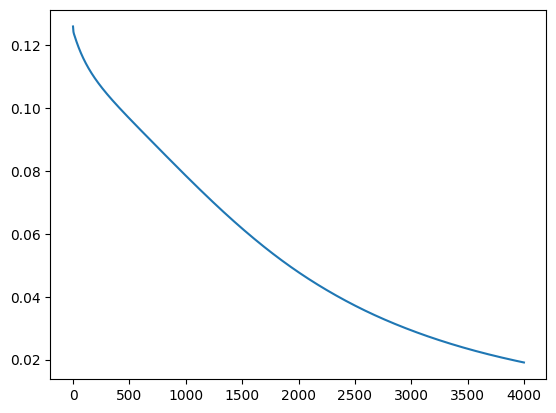

In [10]:
print(x.shape)
print(y.shape)
costs = nn.train(x.T, y.reshape(-1,1).T, epoch_num=1000, batch_size=800)
plt.plot(costs)

In [11]:
print(nn.params)
print(nn.params[0])

(array([[-0.75769176,  0.24230824],
       [-0.70878825, -0.29121175],
       [-0.78606596, -0.21393404],
       ...,
       [ 0.28627807,  0.71372193],
       [ 0.59416422,  0.40583578],
       [ 0.14319715,  0.85680285]]), array([[-0.12503703],
       [-0.19312938],
       [ 0.29297979],
       ...,
       [ 0.26441837],
       [-0.52468578],
       [ 0.55082906]]), array([[-0.02702141,  0.01949046,  0.01870399, ..., -0.1222856 ,
        -0.0095163 ,  0.14355354]]), array([[-0.00187591]]))
[[-0.75769176  0.24230824]
 [-0.70878825 -0.29121175]
 [-0.78606596 -0.21393404]
 ...
 [ 0.28627807  0.71372193]
 [ 0.59416422  0.40583578]
 [ 0.14319715  0.85680285]]


(2, 2000)
(2000,)
(2000, 2)
[-0.02702141  0.01949046  0.01870399 ... -0.1222856  -0.0095163
  0.14355354]


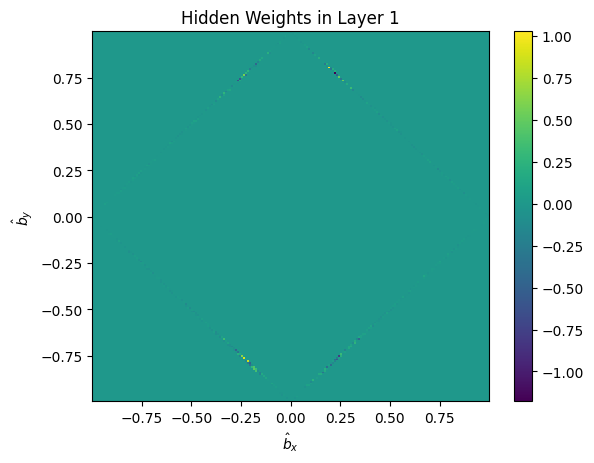

In [12]:
wh1, wn1 = bounds.nn_wnorm(nn.params[0].T)
print(wh1.shape)
print(wn1.shape)
print(nn.params[0].shape)
print(nn.params[2][0]*wn1)
hinfo, xedge, yedge , _ = plt.hist2d(wh1.T[:,0], wh1.T[:,1], bins=200, weights=nn.params[2][0]*wn1)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

[[-0.64853845 -0.49654997 -0.23739754 ...  0.68456353  0.3225176
  -0.00258475]]


Text(0, 0.5, 'y')

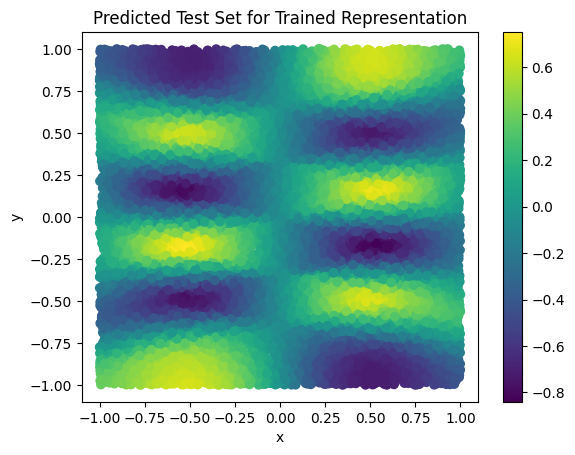

In [13]:
ref = NeuralNet.forward_pass(xt.T, nn.params,'regression')
print(ref[0])
plt.scatter(xt[:,0], xt[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Trained Representation')
plt.xlabel('x')
plt.ylabel('y')

In [14]:
ref[1]

{'X': array([[ 0.36489145, -0.71912734, -0.10322063, ..., -0.45568363,
          0.26202719, -0.59799758],
        [-0.89137166,  0.24299652, -0.38692142, ..., -0.14626622,
          0.76496877, -0.68758688]]),
 'W0': array([[-0.75769176,  0.24230824],
        [-0.70878825, -0.29121175],
        [-0.78606596, -0.21393404],
        ...,
        [ 0.28627807,  0.71372193],
        [ 0.59416422,  0.40583578],
        [ 0.14319715,  0.85680285]]),
 'b0': array([[-0.12503703],
        [-0.19312938],
        [ 0.29297979],
        ...,
        [ 0.26441837],
        [-0.52468578],
        [ 0.55082906]]),
 'z1': array([[-0.61749898,  0.47871988, -0.14058186, ...,  0.18478919,
         -0.13821464,  0.16145283],
        [-0.19218226,  0.24581619, -0.00729175, ...,  0.17244827,
         -0.60161907,  0.43095765],
        [ 0.19684578,  0.80627609,  0.45689368, ...,  0.68246851,
         -0.07664372,  0.91014357],
        ...,
        [-0.26731271,  0.23197992, -0.04128573, ...,  0.02957273,
  

In [15]:
NeuralNet.back_pass(yt.reshape(1,-1), ref[0], 'regression', ref[1])

(array([[-2.19257375e-08,  6.10658192e-09],
        [ 1.52104714e-08,  2.69868033e-09],
        [ 1.41043135e-08,  1.52457091e-09],
        ...,
        [ 2.34158032e-08,  7.57422280e-08],
        [ 2.54430017e-09,  2.11029454e-09],
        [-2.30845734e-08, -8.18996332e-08]]),
 array([[ 3.80372789e-08],
        [-2.50248506e-08],
        [-4.19650304e-08],
        ...,
        [ 2.90634977e-07],
        [ 3.54149914e-09],
        [-3.80026779e-07]]),
 array([[-4.93555152e-07, -3.45495002e-07, -1.26753609e-06, ...,
         -1.12532910e-06, -5.35913290e-08, -1.97004737e-06]]),
 array([[-3.31061069e-06]]))

In [16]:
print(nn.params[0].shape)
print(nn.params[1].shape)
print(nn.params[2].shape)
print(nn.params[3].shape)
print(wn1.reshape(-1,1).shape)
print((nn.params[1]/wn1.reshape(-1,1)).shape)

(2000, 2)
(2000, 1)
(1, 2000)
(1, 1)
(2000, 1)
(2000, 1)


(1, 16000)


Text(0, 0.5, 'y')

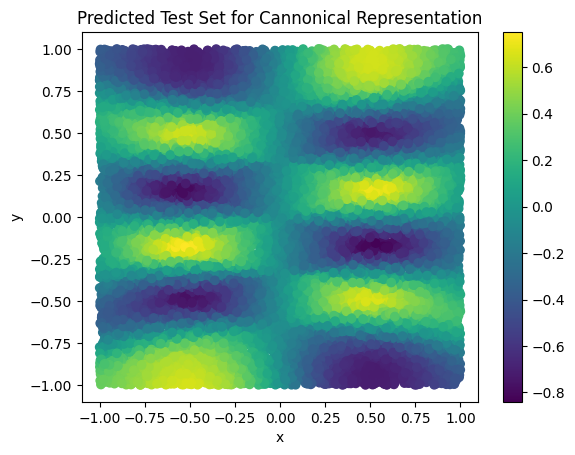

In [17]:
ref = NeuralNet.forward_pass(xt.T, (wh1.T,(nn.params[1]/wn1.reshape(-1,1)),(nn.params[2]*wn1.reshape(1,-1)),nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xt[:,0], xt[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

In [18]:
print(((nn.params[1]/wn1.reshape(-1,1))*256).astype('int').astype('float').T)
print(((nn.params[1]/wn1.reshape(-1,1))*256).T)
print(np.max(((nn.params[1]/wn1.reshape(-1,1))*256)))
print(np.max((wh1.T/128*256)))
print((wh1.T/128*512))
print((wh1.T/128))
print((wh1.T))
print((wh1.T*128))

[[ -32.  -49.   75. ...   67. -134.  141.]]
[[ -32.00948033  -49.44112173   75.00282699 ...   67.69110208
  -134.31955953  141.01223917]]
3171.6280210876307
1.9999487494814003
[[-3.03076703  0.96923297]
 [-2.83515301 -1.16484699]
 [-3.14426384 -0.85573616]
 ...
 [ 1.14511229  2.85488771]
 [ 2.37665689  1.62334311]
 [ 0.5727886   3.4272114 ]]
[[-0.00591947  0.00189303]
 [-0.00553741 -0.00227509]
 [-0.00614114 -0.00167136]
 ...
 [ 0.00223655  0.00557595]
 [ 0.00464191  0.00317059]
 [ 0.00111873  0.00669377]]
[[-0.75769176  0.24230824]
 [-0.70878825 -0.29121175]
 [-0.78606596 -0.21393404]
 ...
 [ 0.28627807  0.71372193]
 [ 0.59416422  0.40583578]
 [ 0.14319715  0.85680285]]
[[ -96.984545     31.015455  ]
 [ -90.72489641  -37.27510359]
 [-100.61644302  -27.38355698]
 ...
 [  36.64359341   91.35640659]
 [  76.05302045   51.94697955]
 [  18.32923518  109.67076482]]


(1, 16000)


Text(0, 0.5, 'y')

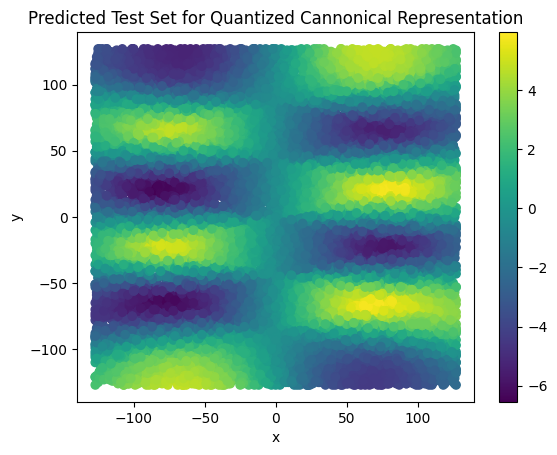

In [19]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T/128*2048).astype('int').astype('float'),((nn.params[1]/wn1.reshape(-1,1))*2048).astype('int').astype('float'),(nn.params[2]*wn1.reshape(1,-1))/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

(1, 16000)


Text(0, 0.5, 'y')

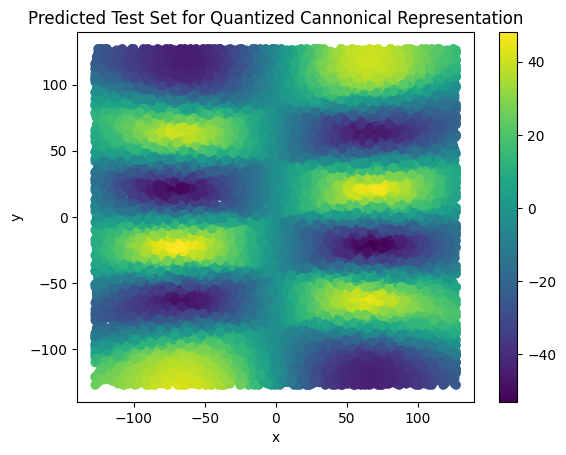

In [20]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T*128).astype('int').astype('float'),((nn.params[1]/wn1.reshape(-1,1))*128*128).astype('int').astype('float'),(nn.params[2]*wn1.reshape(1,-1))/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')

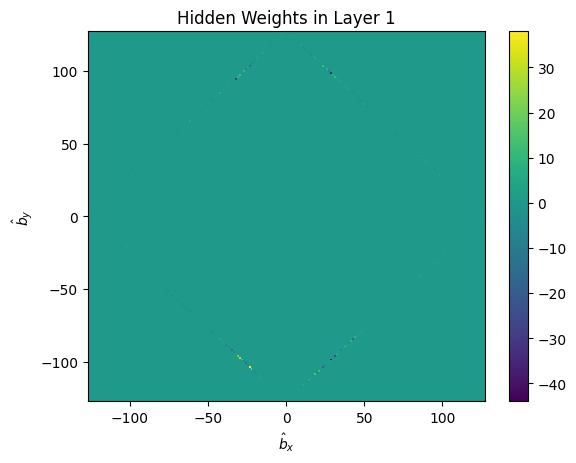

In [21]:
hinfo, xedge, yedge , _ = plt.hist2d((wh1.T[:,0]*128).astype('int8'), (wh1.T[:,1]*128).astype('int8'), bins=200, weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

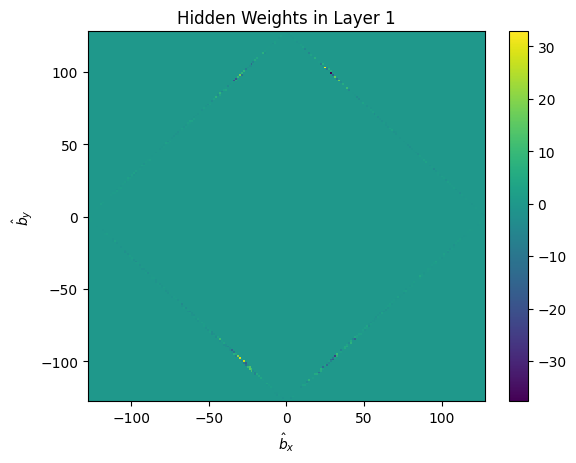

In [22]:
hinfo, xedge, yedge , _ = plt.hist2d((wh1.T[:,0]*128), (wh1.T[:,1]*128), bins=200, weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$\hat{b}_y$')
plt.colorbar()

(2000, 1)
(2000,)
(2000, 1)
(2000,)


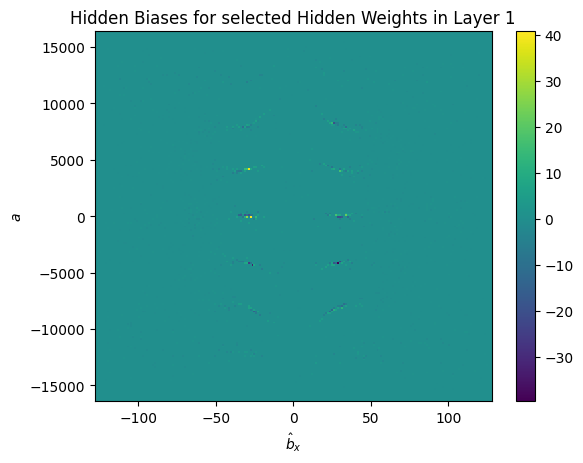

In [23]:
mbias = ((nn.params[1]/wn1.reshape(-1,1))*128*128)
print(mbias.shape)
print((wh1.T[:,0]*128).shape)
print((wh1.T[:,0]*128).reshape(-1,1).shape)
print((nn.params[2][0]*wn1).shape)
hinfoB, xedgeB, yedgeB , _ = plt.hist2d((wh1.T[:,0]*128), mbias.flatten(), bins=200, range=[[-128,128],[-128*128,128*128]], weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Biases for selected Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$a$')
plt.colorbar()

(2000, 1)
(2000,)
(2000, 1)
(2000,)


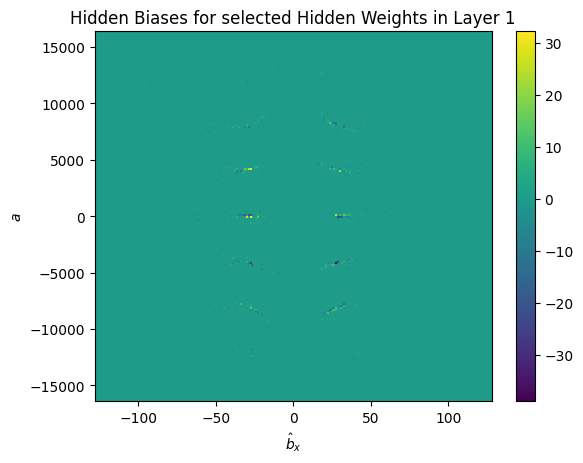

In [24]:
mbias = ((nn.params[1]/wn1.reshape(-1,1))*128*128)
print(mbias.shape)
print((wh1.T[:,0]*128).shape)
print((wh1.T[:,0]*128).reshape(-1,1).shape)
print((nn.params[2][0]*wn1).shape)
hinfoB, xedgeB, yedgeB , _ = plt.hist2d((wh1.T[:,0]*128).astype('int'), mbias.flatten().astype('int'), bins=200, range=[[-128,128],[-128*128,128*128]], weights=nn.params[2][0]*wn1*32)
plt.title('Hidden Biases for selected Hidden Weights in Layer 1')
plt.xlabel('$\hat{b}_x$')
plt.ylabel('$a$')
plt.colorbar()

In [25]:
qparams = {}
wparams = {}
for i in range(wh1.T.shape[0]):
    #qp = tuple(list((wh1.T[i,:]*128).astype('int'))+list(((nn.params[1]/wn1.reshape(-1,1))*128*128).reshape(-1,1).astype('int')[i]))
    #print(qp)
    qp = tuple((wh1.T[i,:]*32).astype('int'))
    twh1 = tuple((wh1.T[i,:]*32).astype('int'))
    #print(twh1)
    if not twh1 in wparams:
        wparams[twh1]=(nn.params[2][0][i]*wn1[i])
    else:
        wparams[twh1]+=(nn.params[2][0][i]*wn1[i])
    if not qp in qparams:
        qparams[qp]=[]
        qparams[qp].append([nn.params[2][0][i]*wn1[i],((nn.params[1]/wn1.reshape(-1,1))*32*32).reshape(-1,1).astype('int')[i][0]])
    else:
        qparams[qp].append([nn.params[2][0][i]*wn1[i],((nn.params[1]/wn1.reshape(-1,1))*32*32).reshape(-1,1).astype('int')[i][0]])        
print(len(qparams))
print(len(wparams))

124
124


In [26]:
print(qparams)

{(-24, 7): [[-0.027021412283523196, -128], [-0.028861531722084336, 69], [-0.018680832725882456, -218], [0.006776790660698444, 384], [0.026555211391214993, -486], [0.010056190149406969, -411], [-0.021894054064089757, 221], [0.03528581840152334, -669], [0.0022096003492928385, -383], [0.030165360732243535, 643], [-0.00035745753023754744, 1089], [0.021923784667028493, 487], [0.028726260170643548, -506], [-0.009467141074285592, 320], [0.03311966334001678, -558], [0.03455601844524841, 714], [0.021856896072751007, 473], [-0.024370176721202095, 185]], (-22, -9): [[0.019490461244169272, -197], [5.253610118575732e-06, -14683], [-0.03208061633248298, -809], [0.0265387445446913, -18], [1.961450432440397e-06, -1635], [-0.027300214684349285, -837], [-6.040448740639909e-06, -1018], [-0.01477824597369551, -440], [-0.046187761858643595, 727], [1.8697893690229094e-05, -4526], [-0.021297232039032804, -541], [-0.008005310240115672, 510], [-0.02918343506713669, -823]], (-25, -6): [[0.018703991466066553, 30

In [27]:
print(wparams)

{(-24, 7): 0.1205789882587634, (-22, -9): -0.13278373790109535, (-25, -6): -0.1160085179268528, (-27, 4): 0.10811505343999685, (7, 24): -0.6991513105126097, (-16, -15): -0.25729138627266257, (17, 14): -0.0545963713894773, (8, 23): 0.3358908095023501, (-13, 18): -0.00791144885386406, (18, -13): 0.0060659098497799335, (1, 30): -0.03819028386270324, (16, 15): -0.014918757472288224, (6, -25): -0.4571088867620683, (28, -3): -0.06759509858293342, (-14, 17): -0.06533285461714013, (12, -19): 0.17441474875849033, (-12, -19): -0.0016557011027984285, (0, -31): -0.04555417840913612, (-15, -16): -0.21592760063383593, (13, -18): -0.10674670284756868, (-8, -23): -0.6970583340986448, (-15, 16): 0.27728568487710276, (-10, 21): 0.3216546091637931, (-18, -13): -0.07373302484827525, (26, -5): -0.03882323030824423, (-17, 14): -0.17586798939093298, (14, -17): -0.14624606184471461, (12, 19): -0.009383178657483655, (-3, 28): 0.2595592464755181, (27, -4): 0.03404052198319724, (-6, 25): 0.04228174048142205, (13

In [28]:
slw = sorted(wparams.items(),key=lambda item: abs(item[1]))
print(slw[-1])
topres= []
for s in slw:
    if abs(s[1])>0.03*abs(slw[-1][1]):
        topres.append(s[0])
print(topres)
print(len(topres))

((7, -24), -2.0398677987787974)
[(-26, 5), (8, -23), (-14, 17), (28, -3), (-23, 8), (26, 5), (-18, 13), (-18, -13), (-1, -30), (-23, -8), (-11, 20), (15, 16), (-19, 12), (23, -8), (-2, 29), (19, 12), (-29, 2), (24, -7), (5, 26), (-26, -5), (-24, -7), (2, -29), (13, -18), (-27, 4), (14, 17), (-3, -28), (-25, -6), (11, 20), (-4, 27), (-24, 7), (-22, -9), (3, -28), (-20, -11), (20, 11), (14, -17), (23, 8), (3, 28), (12, -19), (22, 9), (-17, 14), (4, 27), (10, 21), (21, -10), (9, 22), (-15, -16), (-4, -27), (-11, -20), (-16, -15), (-3, 28), (-15, 16), (5, -26), (-10, 21), (10, -21), (8, 23), (-6, -25), (-10, -21), (11, -20), (6, -25), (-9, -22), (6, 25), (4, -27), (9, -22), (-5, 26), (-8, -23), (7, 24), (-7, 24), (-8, 23), (-5, -26), (-7, -24), (7, -24)]
70


In [29]:
filter(lambda x: x in topres ,(wh1.T*32).astype('int'))
print((wh1.T*32).astype('int')[0])
print(tuple((wh1.T*32).astype('int')[0]) in topres)

[-24   7]
True


In [30]:
inds = [i for i,x in enumerate((wh1.T*32).astype('int')) if tuple(x) in topres]
print((wh1.T*32).astype('int').astype('float')[inds,:].shape)
print(((nn.params[1]/wn1.reshape(-1,1))*32*32).astype('int').astype('float')[inds,:].shape)
print((nn.params[2]*wn1.reshape(1,-1))[:,inds].shape)

(1143, 2)
(1143, 1)
(1, 1143)


(1, 16000)


Text(0, 0.5, 'y')

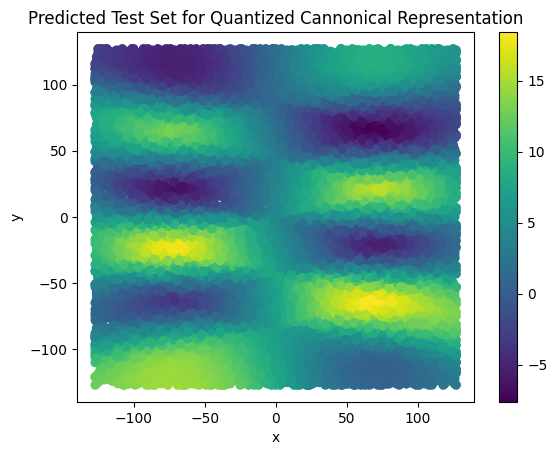

In [31]:
ref = NeuralNet.forward_pass(xtc.T, ((wh1.T*32).astype('int').astype('float')[inds,:],((nn.params[1]/wn1.reshape(-1,1))*32*128).astype('int').astype('float')[inds,:],(nn.params[2]*wn1.reshape(1,-1))[:,inds]/256,nn.params[3]),'regression')
print(ref[0].shape)
plt.scatter(xtc[:,0], xtc[:,1], c=ref[0])
plt.colorbar()
plt.title('Predicted Test Set for Quantized Cannonical Representation')
plt.xlabel('x')
plt.ylabel('y')